# 05 - Merge & Korrelationsanalyse: Forex-Kurse und News-Sentiment

**Ziel:** Forex-Kursdaten und News-Sentiment zusammenführen und analysieren ob es eine Korrelation gibt.

**Frage:** *Wenn die Nachrichten negativ waren — ist der Kurs am nächsten Tag gefallen?*

**Datenquellen:**
- Forex-Kurse: Yahoo Finance (data/raw/forex/yahoo/)
- News-Sentiment: EODHD News API (data/raw/news/eodhd/)

---

## 1. Setup und Imports

In [3]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Darstellung konfigurieren
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print('Setup erfolgreich!')

Setup erfolgreich!


## 2. Daten laden

Wir laden die bereits gespeicherten Rohdaten von der Festplatte — keine API-Calls nötig.

In [4]:
# Konfiguration
PAIRS = ['EUR_USD', 'EUR_CHF', 'GBP_USD']
DATE_RANGE = '2024-01-01_to_2026-03-11'

FOREX_DIR = '../data/raw/forex/yahoo'
NEWS_DIR = '../data/raw/news/eodhd'

print(f'Währungspaare: {PAIRS}')
print(f'Zeitraum: {DATE_RANGE}')

Währungspaare: ['EUR_USD', 'EUR_CHF', 'GBP_USD']
Zeitraum: 2024-01-01_to_2026-03-11


In [5]:
# Forex-Kurse laden (alle 3 Paare)
forex_frames = []

for pair in PAIRS:
    path = os.path.join(FOREX_DIR, f'{pair}_{DATE_RANGE}.csv')
    df = pd.read_csv(path)
    
    # Datum bereinigen (Yahoo hat Timezone im Datum)
    df['date'] = pd.to_datetime(df['Date'], utc=True).dt.date
    df['pair'] = pair
    
    # Nur relevante Spalten behalten
    df = df[['date', 'pair', 'Open', 'High', 'Low', 'Close']].rename(columns={
        'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close'
    })
    forex_frames.append(df)
    print(f'Forex geladen: {pair} ({len(df)} Tage)')

forex = pd.concat(forex_frames, ignore_index=True)
print(f'\nForex gesamt: {len(forex)} Zeilen')

Forex geladen: EUR_USD (567 Tage)
Forex geladen: EUR_CHF (567 Tage)
Forex geladen: GBP_USD (567 Tage)

Forex gesamt: 1701 Zeilen


In [6]:
# News-Sentiment laden (alle 3 Paare)
# Pro Tag gibt es mehrere Artikel -> wir berechnen den Tagesdurchschnitt
news_frames = []

for pair in PAIRS:
    path = os.path.join(NEWS_DIR, f'{pair}_news_{DATE_RANGE}.csv')
    df = pd.read_csv(path)
    
    # Datum bereinigen
    df['date'] = pd.to_datetime(df['date'], utc=True).dt.date
    
    # Aggregation auf Tagesebene: Durchschnitt aller Artikel pro Tag
    daily = df.groupby('date').agg(
        article_count=('title', 'count'),        # Anzahl Artikel
        polarity_mean=('polarity', 'mean'),       # Durchschnittliche Stimmung (-1 bis +1)
        pos_mean=('pos', 'mean'),                 # Positiv-Score
        neg_mean=('neg', 'mean'),                 # Negativ-Score
        neu_mean=('neu', 'mean'),                 # Neutral-Score
    ).reset_index()
    daily['pair'] = pair
    news_frames.append(daily)
    print(f'News geladen: {pair} ({len(df)} Artikel, {len(daily)} Tage mit News)')

news = pd.concat(news_frames, ignore_index=True)
print(f'\nNews gesamt: {len(news)} Tage mit News')

News geladen: EUR_USD (12519 Artikel, 709 Tage mit News)
News geladen: EUR_CHF (12 Artikel, 10 Tage mit News)
News geladen: GBP_USD (8368 Artikel, 699 Tage mit News)

News gesamt: 1418 Tage mit News


## 3. Zusammenführen (Merge)

Wir verbinden Kurse und News über das Datum und das Währungspaar.

Wir verwenden `how='left'`: Jeder Handelstag bleibt erhalten, auch wenn es an dem Tag keine News gibt.

In [7]:
# Merge: Forex + News zusammenkleben
merged = pd.merge(forex, news, on=['date', 'pair'], how='left')

print(f'Shape: {merged.shape}')
print(f'Spalten: {list(merged.columns)}')
print(f'\nZeitraum: {merged["date"].min()} bis {merged["date"].max()}')
print(f'\nZeilen pro Währungspaar:')
print(merged['pair'].value_counts())
print(f'\nTage MIT News-Sentiment: {merged["polarity_mean"].notna().sum()}')
print(f'Tage OHNE News-Sentiment: {merged["polarity_mean"].isna().sum()} (Feiertage, Wochenenden in News)')

Shape: (1701, 11)
Spalten: ['date', 'pair', 'open', 'high', 'low', 'close', 'article_count', 'polarity_mean', 'pos_mean', 'neg_mean', 'neu_mean']

Zeitraum: 2024-01-01 bis 2026-03-10

Zeilen pro Währungspaar:
pair
EUR_USD    567
EUR_CHF    567
GBP_USD    567
Name: count, dtype: int64

Tage MIT News-Sentiment: 1060
Tage OHNE News-Sentiment: 641 (Feiertage, Wochenenden in News)


In [8]:
# Erste 10 Zeilen anzeigen
merged.head(10)

,date,pair,open,high,low,close,article_count,polarity_mean,pos_mean,neg_mean,neu_mean
0,2024-01-01,EUR_USD,1.105583,1.105339,1.103997,1.105583,1.0,0.000000,0.000000,0.000000,0.000000
1,2024-01-02,EUR_USD,1.103875,1.104606,1.094200,1.103875,24.0,-0.060417,0.066083,0.081292,0.852583
2,2024-01-03,EUR_USD,1.094176,1.096700,1.089871,1.094176,19.0,-0.039105,0.044421,0.065789,0.837211
3,2024-01-04,EUR_USD,1.092777,1.097021,1.091703,1.092777,21.0,0.005190,0.049619,0.072095,0.878286
4,2024-01-05,EUR_USD,1.094739,1.099638,1.087985,1.094739,26.0,0.110654,0.058269,0.050500,0.852769
5,2024-01-08,EUR_USD,1.094224,1.097815,1.092454,1.094224,34.0,0.010441,0.057176,0.058824,0.854559
6,2024-01-09,EUR_USD,1.095170,1.096732,1.091262,1.095170,22.0,-0.004318,0.054909,0.072000,0.827591
7,2024-01-10,EUR_USD,1.093243,1.096972,1.092335,1.093243,26.0,0.049154,0.055269,0.057500,0.887269
8,2024-01-11,EUR_USD,1.097514,1.099143,1.093147,1.097514,27.0,-0.056593,0.065556,0.064222,0.870222
9,2024-01-12,EUR_USD,1.098165,1.098660,1.093709,1.098165,23.0,-0.024870,0.044696,0.073478,0.838261


## 4. Tägliche Kursveränderung berechnen

Um die Korrelation zu messen, brauchen wir nicht den absoluten Kurs, sondern **wie stark er sich verändert hat**.

Beispiel:
- Kurs heute: 1.10 → Kurs morgen: 1.09 → Veränderung: **-0.9%** (gefallen)
- Kurs heute: 1.10 → Kurs morgen: 1.12 → Veränderung: **+1.8%** (gestiegen)

In [9]:
# Tägliche Kursveränderung pro Währungspaar berechnen
merged = merged.sort_values(['pair', 'date']).reset_index(drop=True)

# Prozentuale Veränderung (pct_change) pro Paar separat berechnen
merged['close_change'] = merged.groupby('pair')['close'].pct_change() * 100

# Morgige Kursveränderung (Sentiment von heute -> Kurs von morgen)
# Das ist die eigentliche Frage: Sagt das Sentiment von heute den Kurs von morgen voraus?
merged['close_change_next_day'] = merged.groupby('pair')['close_change'].shift(-1)

print('Kursveränderung hinzugefügt:')
print(merged[['date', 'pair', 'close', 'close_change', 'polarity_mean', 'close_change_next_day']].head(10))

Kursveränderung hinzugefügt:
         date     pair    close  close_change  polarity_mean  \
0  2024-01-01  EUR_CHF  0.92837           NaN            NaN   
1  2024-01-02  EUR_CHF  0.92917      0.086174            NaN   
2  2024-01-03  EUR_CHF  0.93025      0.116230            NaN   
3  2024-01-04  EUR_CHF  0.92770     -0.274120            NaN   
4  2024-01-05  EUR_CHF  0.93060      0.312602            NaN   
5  2024-01-08  EUR_CHF  0.93083      0.024717            NaN   
6  2024-01-09  EUR_CHF  0.92870     -0.228831            NaN   
7  2024-01-10  EUR_CHF  0.93185      0.339189            NaN   
8  2024-01-11  EUR_CHF  0.93338      0.164189            NaN   
9  2024-01-12  EUR_CHF  0.93450      0.119991            NaN   

   close_change_next_day  
0               0.086174  
1               0.116230  
2              -0.274120  
3               0.312602  
4               0.024717  
5              -0.228831  
6               0.339189  
7               0.164189  
8               0.11999

## 5. Daten speichern

Der fertige kombinierte Datensatz wird als CSV gespeichert.

In [10]:
# Kombinierten Datensatz speichern
FINAL_DIR = '../data/final'
os.makedirs(FINAL_DIR, exist_ok=True)

output_path = os.path.join(FINAL_DIR, 'forex_news_merged.csv')
merged.to_csv(output_path, index=False)

print(f'Gespeichert: {output_path}')
print(f'{len(merged)} Zeilen, {len(merged.columns)} Spalten')

Gespeichert: ../data/final\forex_news_merged.csv
1701 Zeilen, 13 Spalten


## 6. Korrelationsanalyse

Jetzt kommt die eigentliche Frage: **Gibt es eine Korrelation zwischen News-Sentiment und Kursveränderung?**

Wir schauen zwei Varianten:
1. **Gleicher Tag:** Sentiment heute ↔ Kursveränderung heute
2. **Nächster Tag:** Sentiment heute ↔ Kursveränderung morgen (interessanter für Vorhersage)

In [11]:
# Pearson-Korrelation pro Währungspaar berechnen
print('KORRELATION: Sentiment vs. Kursveränderung')
print('=' * 55)
print(f'{"Paar":<12} {"Gleicher Tag":>15} {"Nächster Tag":>15}')
print('-' * 55)

for pair in PAIRS:
    df_pair = merged[merged['pair'] == pair].dropna(subset=['polarity_mean', 'close_change'])
    
    # Korrelation gleicher Tag
    corr_same = df_pair['polarity_mean'].corr(df_pair['close_change'])
    
    # Korrelation nächster Tag
    df_next = df_pair.dropna(subset=['close_change_next_day'])
    corr_next = df_next['polarity_mean'].corr(df_next['close_change_next_day'])
    
    print(f'{pair:<12} {corr_same:>+15.4f} {corr_next:>+15.4f}')

print('=' * 55)
print('Wert nahe 0 = keine Korrelation')
print('Wert nahe +1 = positive Korrelation (positiv -> Kurs steigt)')
print('Wert nahe -1 = negative Korrelation (positiv -> Kurs fällt)')

KORRELATION: Sentiment vs. Kursveränderung
Paar            Gleicher Tag    Nächster Tag
-------------------------------------------------------
EUR_USD              +0.1704         -0.0868
EUR_CHF              -0.1687         -0.3467
GBP_USD              +0.1356         -0.0379
Wert nahe 0 = keine Korrelation
Wert nahe +1 = positive Korrelation (positiv -> Kurs steigt)
Wert nahe -1 = negative Korrelation (positiv -> Kurs fällt)


## 7. Visualisierung

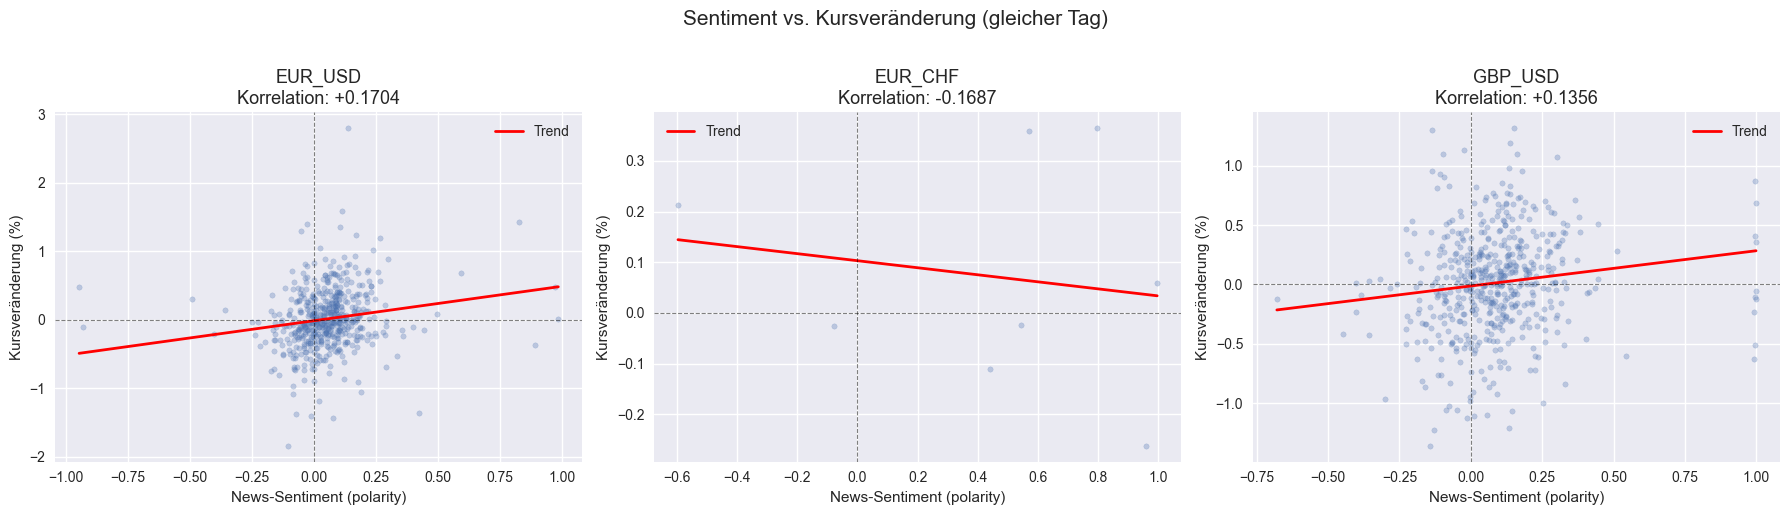

In [12]:
# Scatter-Plots: Sentiment vs. Kursveränderung (gleicher Tag)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pair in zip(axes, PAIRS):
    df_pair = merged[(merged['pair'] == pair)].dropna(subset=['polarity_mean', 'close_change'])
    
    corr = df_pair['polarity_mean'].corr(df_pair['close_change'])
    
    ax.scatter(df_pair['polarity_mean'], df_pair['close_change'], alpha=0.3, s=15)
    
    # Trendlinie
    z = np.polyfit(df_pair['polarity_mean'], df_pair['close_change'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_pair['polarity_mean'].min(), df_pair['polarity_mean'].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Trend')
    
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(f'{pair}\nKorrelation: {corr:+.4f}', fontsize=13)
    ax.set_xlabel('News-Sentiment (polarity)')
    ax.set_ylabel('Kursveränderung (%)')
    ax.legend()

plt.suptitle('Sentiment vs. Kursveränderung (gleicher Tag)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

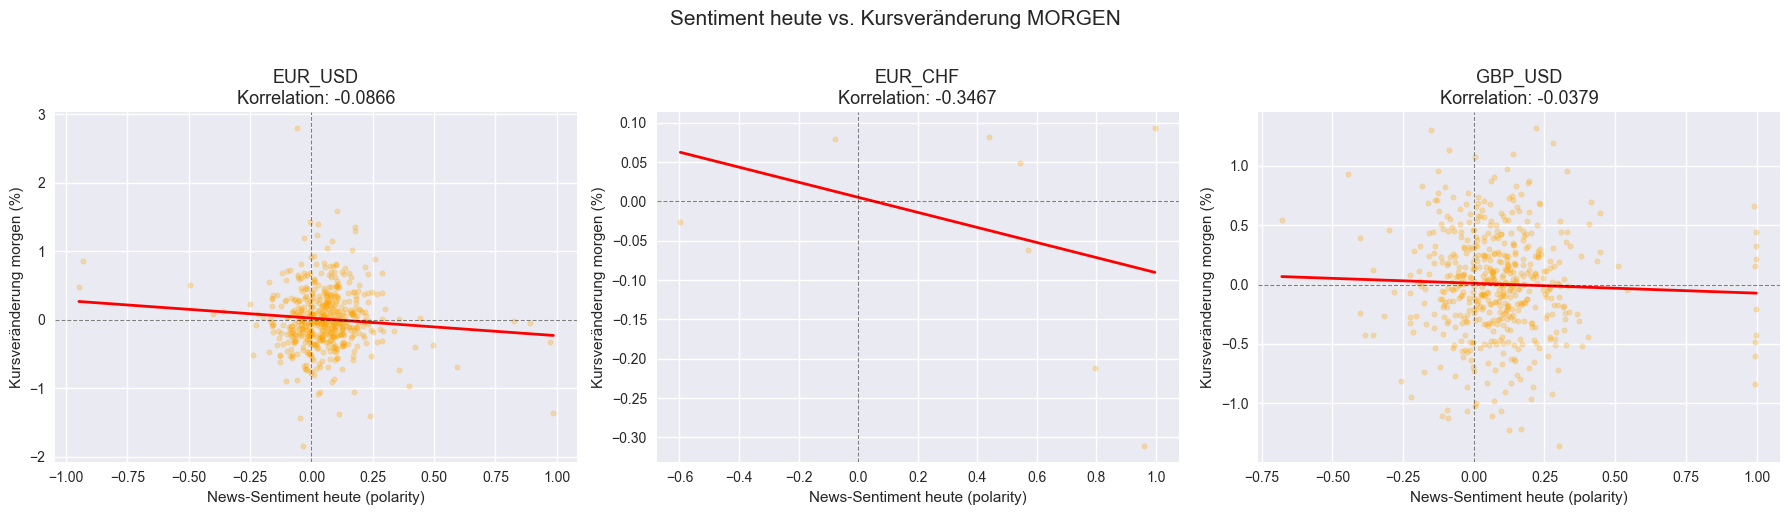

In [13]:
# Scatter-Plots: Sentiment vs. Kursveränderung NÄCHSTER TAG
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pair in zip(axes, PAIRS):
    df_pair = merged[(merged['pair'] == pair)].dropna(subset=['polarity_mean', 'close_change_next_day'])
    
    corr = df_pair['polarity_mean'].corr(df_pair['close_change_next_day'])
    
    ax.scatter(df_pair['polarity_mean'], df_pair['close_change_next_day'], alpha=0.3, s=15, color='orange')
    
    # Trendlinie
    z = np.polyfit(df_pair['polarity_mean'], df_pair['close_change_next_day'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_pair['polarity_mean'].min(), df_pair['polarity_mean'].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2)
    
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(f'{pair}\nKorrelation: {corr:+.4f}', fontsize=13)
    ax.set_xlabel('News-Sentiment heute (polarity)')
    ax.set_ylabel('Kursveränderung morgen (%)')

plt.suptitle('Sentiment heute vs. Kursveränderung MORGEN', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

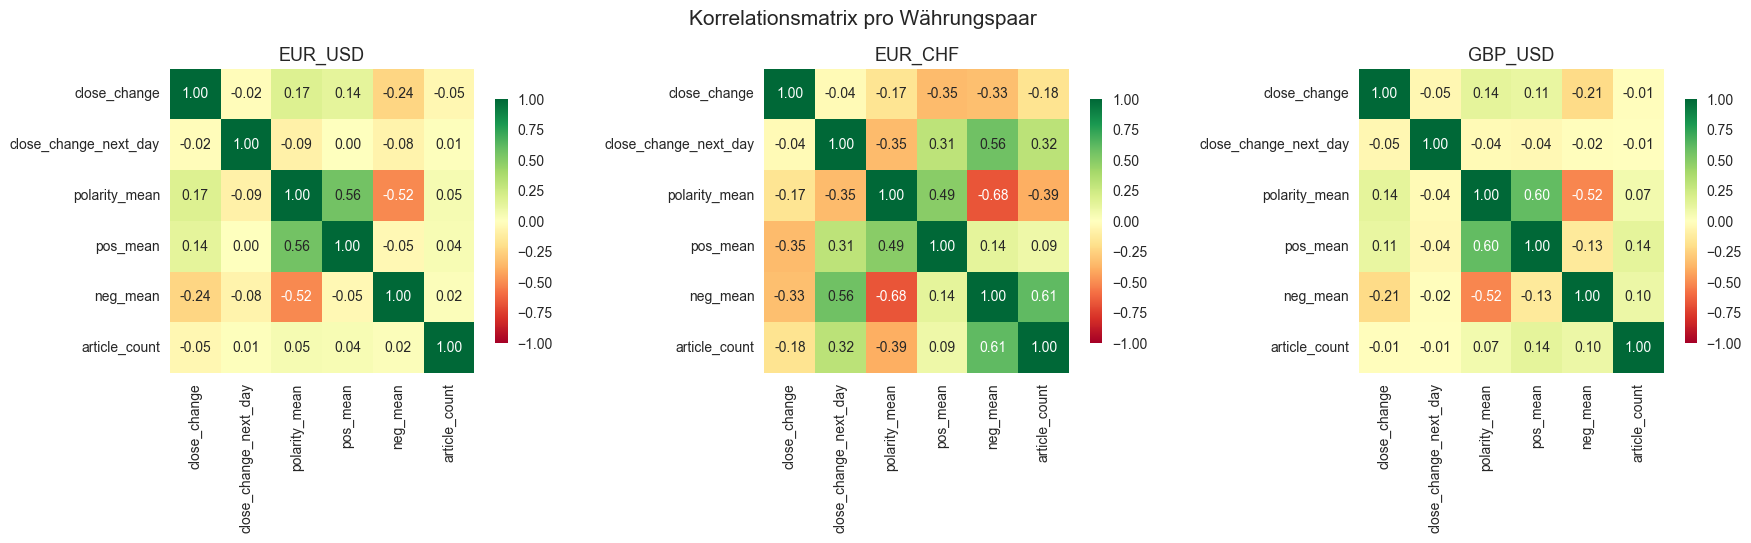

In [14]:
# Korrelations-Heatmap: Alle Variablen auf einmal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

corr_cols = ['close_change', 'close_change_next_day', 'polarity_mean', 'pos_mean', 'neg_mean', 'article_count']

for ax, pair in zip(axes, PAIRS):
    df_pair = merged[merged['pair'] == pair][corr_cols].dropna()
    corr_matrix = df_pair.corr()
    
    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.2f',
        cmap='RdYlGn', center=0,
        vmin=-1, vmax=1,
        ax=ax, square=True,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(f'{pair}', fontsize=13)

plt.suptitle('Korrelationsmatrix pro Währungspaar', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

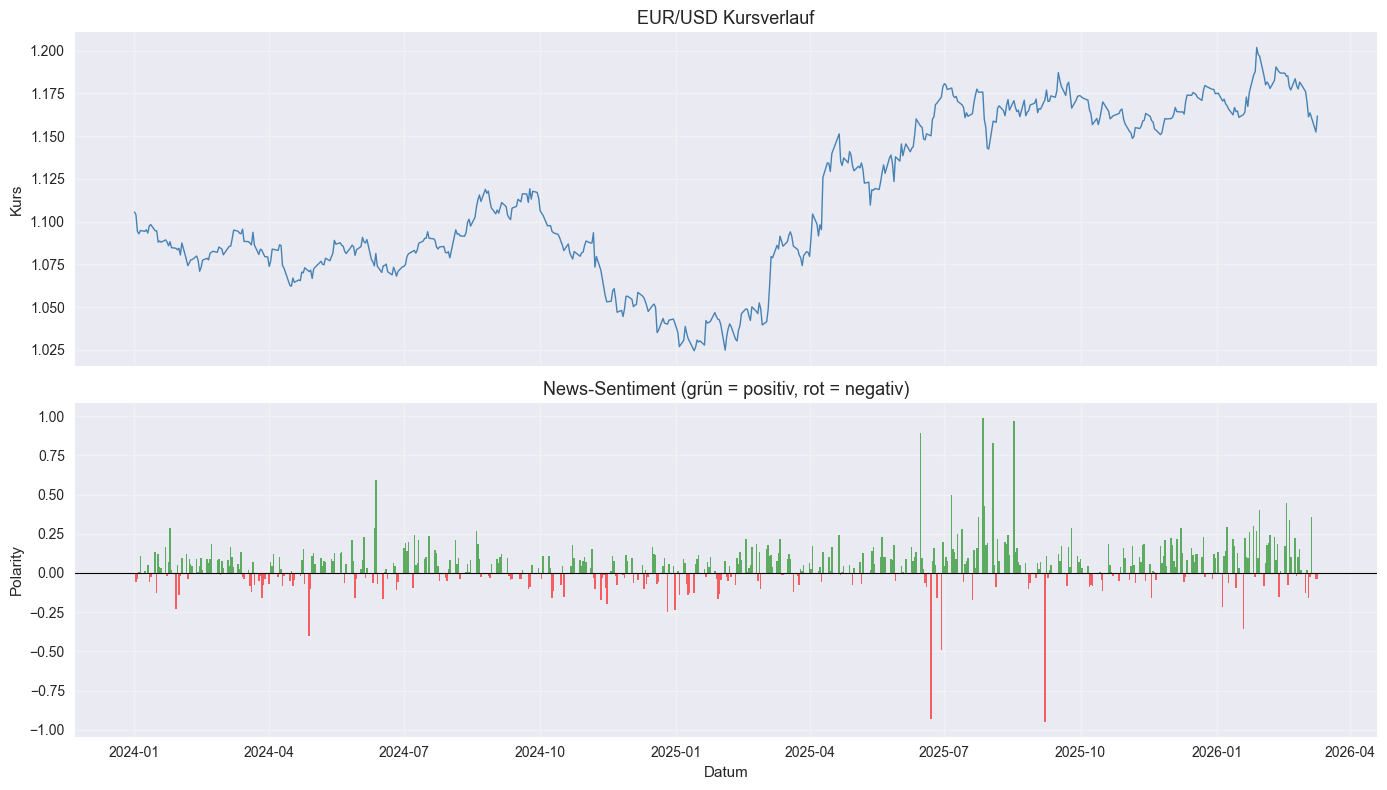

: 

In [ ]:
# Kursverlauf + Sentiment über Zeit (EUR/USD als Beispiel)
df_eur = merged[merged['pair'] == 'EUR_USD'].copy()
df_eur['date'] = pd.to_datetime(df_eur['date'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Kursverlauf
ax1.plot(df_eur['date'], df_eur['close'], color='steelblue', linewidth=1)
ax1.set_title('EUR/USD Kursverlauf', fontsize=13)
ax1.set_ylabel('Kurs')
ax1.grid(True, alpha=0.3)

# Sentiment
df_news = df_eur.dropna(subset=['polarity_mean'])
colors = ['green' if x > 0 else 'red' for x in df_news['polarity_mean']]
ax2.bar(df_news['date'], df_news['polarity_mean'], color=colors, alpha=0.6, width=1)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('News-Sentiment (grün = positiv, rot = negativ)', fontsize=13)
ax2.set_ylabel('Polarity')
ax2.set_xlabel('Datum')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Zusammenfassung

### Was wir gemacht haben:
1. Forex-Kurse (Yahoo Finance) geladen
2. News-Sentiment (EODHD) auf Tagesebene aggregiert
3. Beide Datensätze nach `date` und `pair` zusammengeführt
4. Tägliche Kursveränderung berechnet
5. Korrelation zwischen Sentiment und Kursveränderung analysiert

### Erkenntnisse:
- *(nach Ausführung ausfüllen)*

### Nächste Schritte:
- Sentiment-Analyse auf Webscraping-Daten (VADER)
- Tiefere statistische Tests (p-Wert, Rolling Correlation)
- Bericht schreiben